In [1]:
import sys
print(sys.executable)


c:\Users\jasmineyeo\AppData\Local\anaconda3\envs\JSY_SpMod\python.exe


In [17]:
from helper import axons

dFF_out, denoised_dFF, sps, kept_groups = axons.get_independent_axons(
    {
        'twop_rate': 10.
    },
    matpath='D:\\V1_SpatialModulation\\2p\\V1window\\JSY061_ChronicImaging_Axonal\\260202_JSY_JSY061_SpMod_AxonalImaging_Day1\\TSeries-02022026-1804-001\\TSeries-02022026-1804-001_data.mat',
    cc_thresh=0.25, gcc_thresh=0.95)


In [8]:
# load mat file from the matpath as data    
from scipy import io
mat = io.loadmat('D:\\V1_SpatialModulation\\2p\\V1window\\JSY061_ChronicImaging_Axonal\\260202_JSY_JSY061_SpMod_AxonalImaging_Day1\\TSeries-02022026-1804-001\\TSeries-02022026-1804-001_data.mat')
data = mat['data'].item()

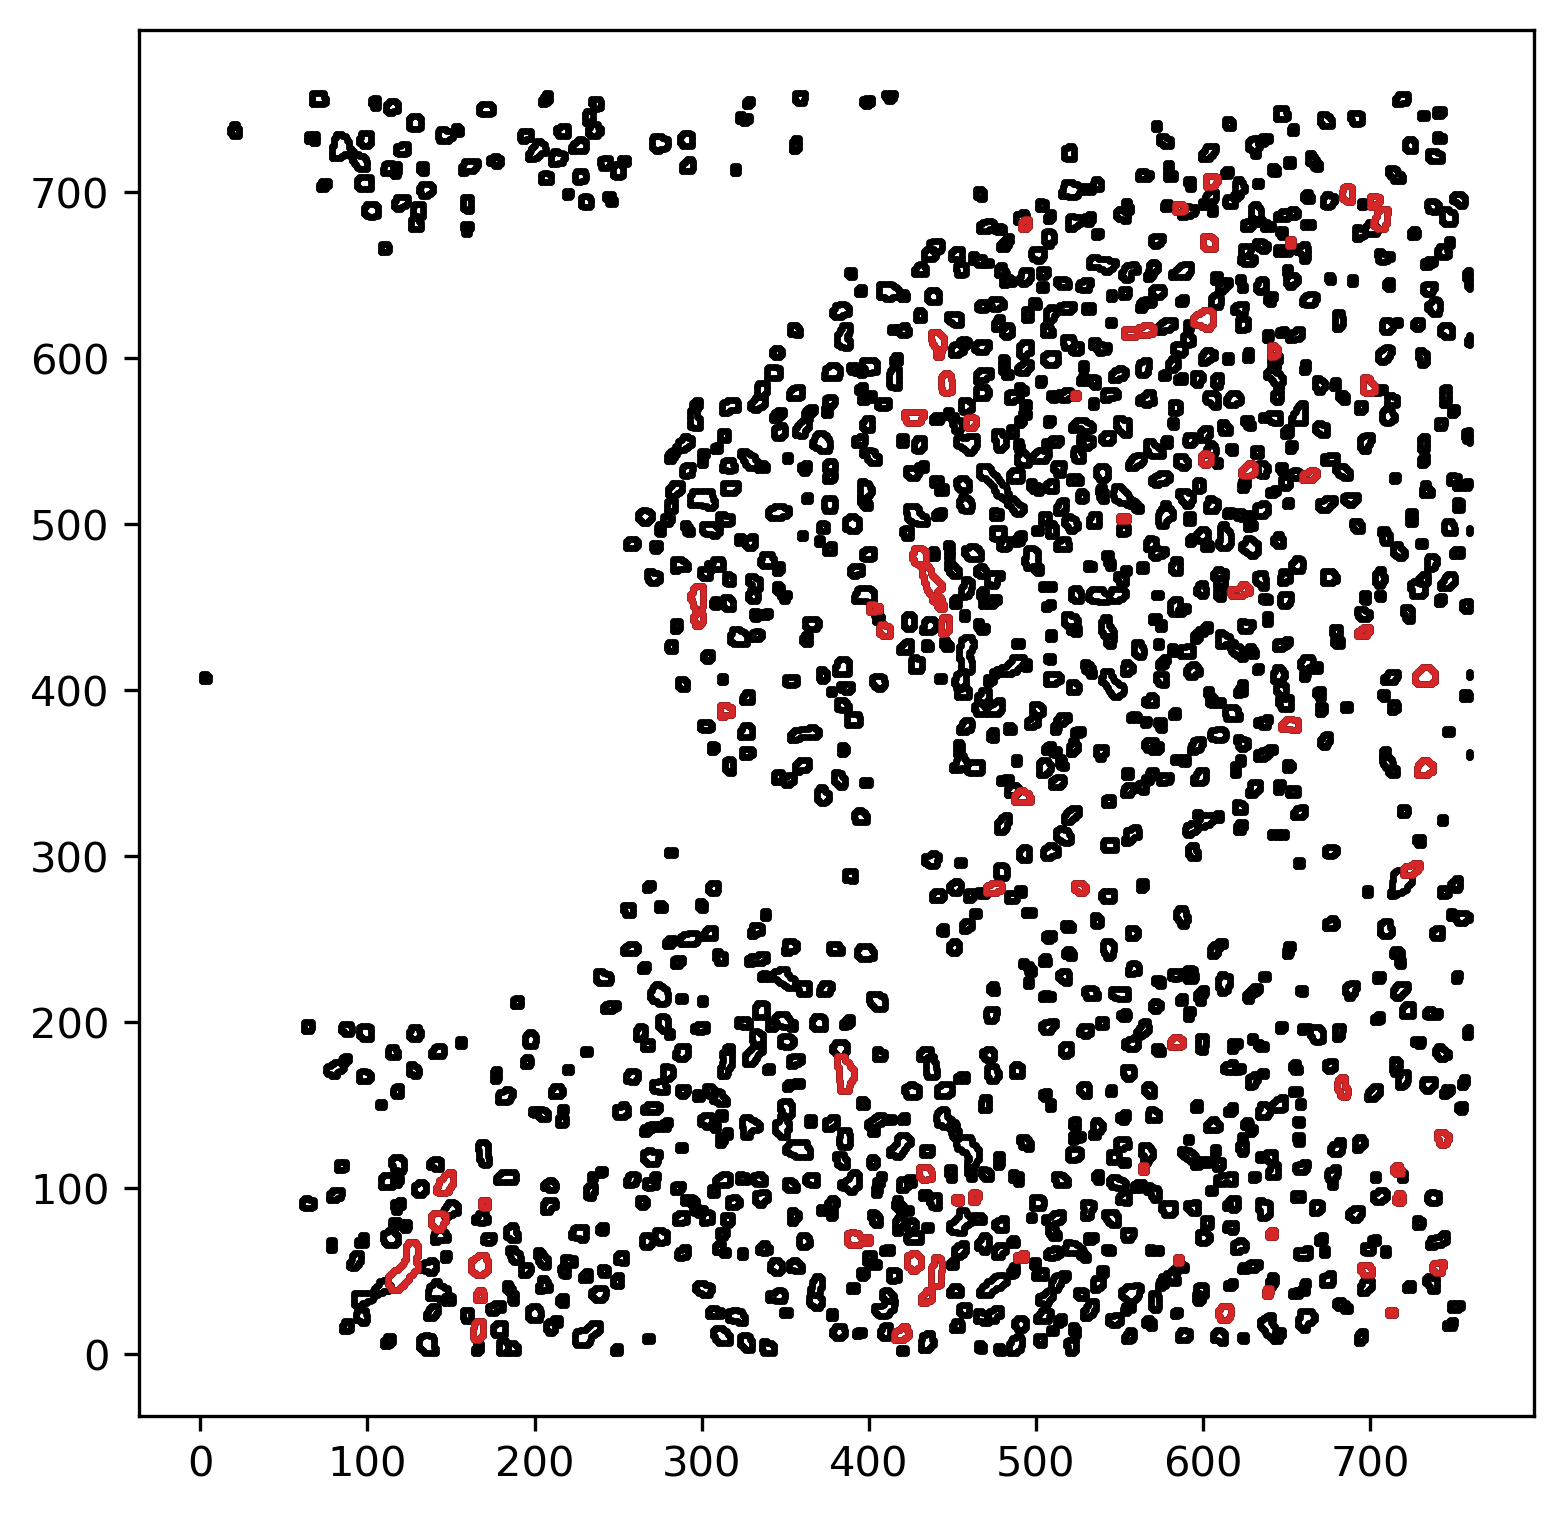

In [16]:
import matplotlib.pyplot as plt
import numpy as np


plt.figure(dpi=300, figsize=(6,6))
for c in range(np.size(mat['data']['cellMasks'][0][0], 1)):
    pts = mat['data']['cellMasks'][0][0][:,c][0]
    for i in range(np.size(pts, 0)):
        plt.plot(pts[i,0], pts[i,1], 'k.', ms=1)

# plt.figure(dpi=300, figisze=(6,6))
for c in range(np.size(mat['data']['cellMasks'][0][0], 1)):
    pts = mat['data']['cellMasks'][0][0][:,c][0]
    for i in range(np.size(pts, 0)):
        plt.plot(pts[i,0], pts[i,1], 'k.', ms=1)


for gi, g in enumerate(kept_groups):
    if len(g) > 1:
        for gx in g:
            pts = mat['data']['cellMasks'][0][0][:,gx][0]
            for i in range(np.size(pts, 0)):
                plt.plot(pts[i,0], pts[i,1], '.', color='tab:red', ms=1)

**for registered data**

In [2]:
from helper import axons

dFF_out, denoised_dFF, sps, kept_groups = axons.get_independent_axons(
    {
        'twop_rate': 10.
    },
    matpath='D:\\V1_SpatialModulation\\2p\\V1window\\JSY061_ChronicImaging_Axonal\\260202_JSY_JSY061_SpMod_AxonalImaging_Day1\\TSeries-02022026-1804-001\\TSeries-02022026-1804-001_registered_data.mat',
    cc_thresh=0.25, gcc_thresh=0.95)


In [3]:
# load mat file from the matpath as data    
from scipy import io
mat = io.loadmat('D:\\V1_SpatialModulation\\2p\\V1window\\JSY061_ChronicImaging_Axonal\\260202_JSY_JSY061_SpMod_AxonalImaging_Day1\\TSeries-02022026-1804-001\\TSeries-02022026-1804-001_registered_data.mat')
data = mat['data'].item()

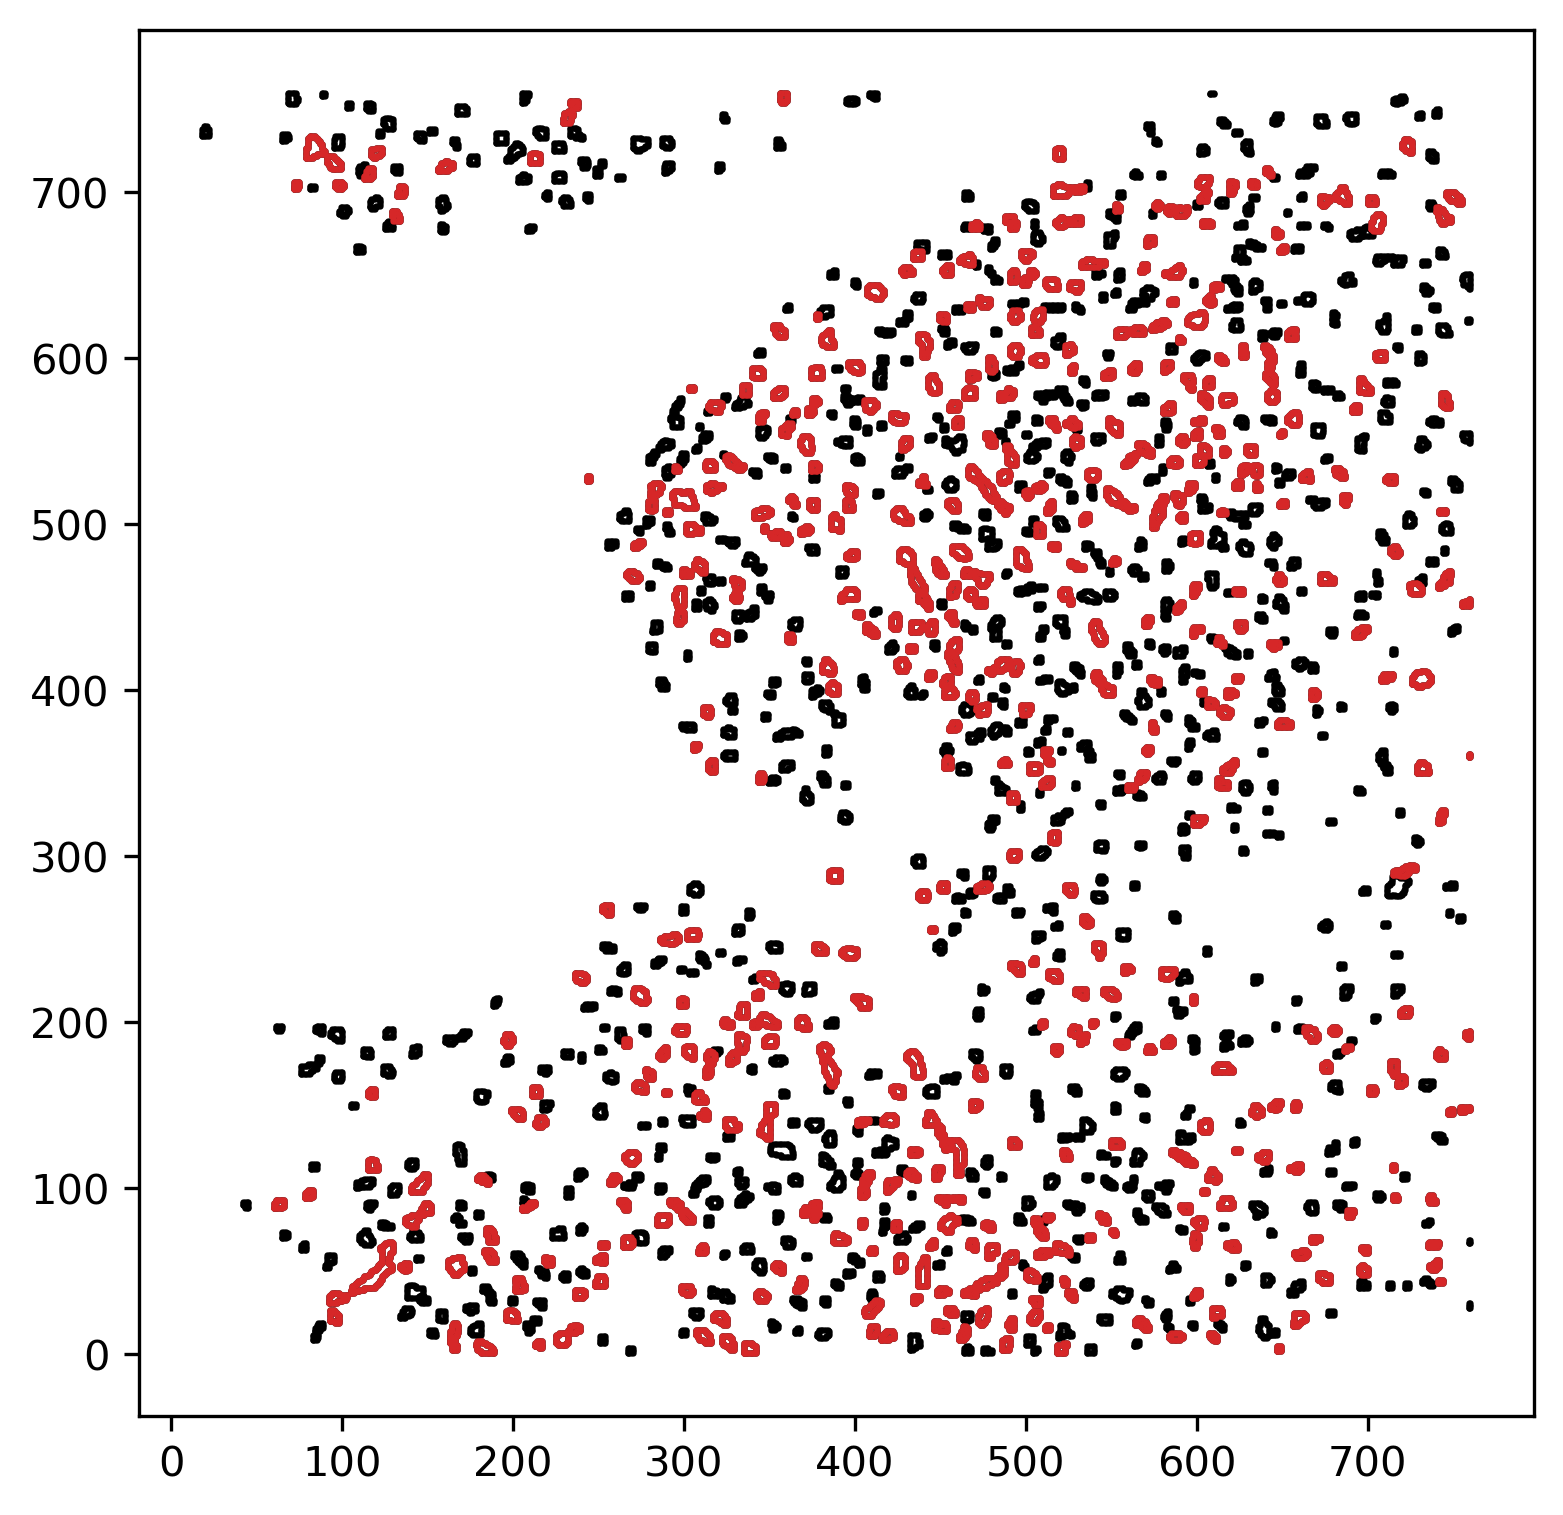

In [4]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(dpi=300, figsize=(6,6))
for c in range(np.size(mat['data']['cellMasks'][0][0], 1)):
    pts = mat['data']['cellMasks'][0][0][:,c][0]
    for i in range(np.size(pts, 0)):
        plt.plot(pts[i,0], pts[i,1], 'k.', ms=1)
        # invert y-axis
        plt.gca().invert_yaxis()

# # plt.figure(dpi=300, figisze=(6,6))

# for c in range(np.size(mat['data']['cellMasks'][0][0], 1)):
#     pts = mat['data']['cellMasks'][0][0][:,c][0]
#     for i in range(np.size(pts, 0)):
#         plt.plot(pts[i,0], pts[i,1], 'k.', ms=1)
        
        


for gi, g in enumerate(kept_groups):
    if len(g) > 1:
        for gx in g:
            pts = mat['data']['cellMasks'][0][0][:,gx][0]
            for i in range(np.size(pts, 0)):
                plt.plot(pts[i,0], pts[i,1], '.', color='tab:red', ms=1)
                # invert y-axis
                plt.gca().invert_yaxis()

In [5]:
from matplotlib import pyplot as plt

# plot the dff traces of the kept groups
plt.figure(dpi=300, figsize=(10,6))
n_rois = dFF_out.shape[0]  # 821

for gi, g in enumerate(10):
    # Filter to only valid indices
    valid_g = [idx for idx in g if idx < n_rois]
    
    if len(valid_g) > 1:
        for gx in valid_g:
            plt.plot(dFF_out[gx, :1000], color='tab:red', alpha=0.5)
    elif len(valid_g) == 1:
        plt.plot(dFF_out[valid_g[0], :1000], color='k', alpha=0.5)

TypeError: 'int' object is not iterable

<Figure size 3000x1800 with 0 Axes>